# Example: Pricing Zero-Coupon Treasury Bills Using NPV
In this example, we will compute the price of zero-coupon United States Treasury Bills, or __T-bills__ using the Net Present Value (NPV) approach.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Represent and price zero-coupon cash flows:__ Identify the purchase-date outflow and the single face-value receipt at maturity, then apply the zero-NPV condition under an explicitly stated yield convention.
> * __Relate bill prices and yields:__ Explain why a bill's price falls as its quoted investment rate rises, and compute that inverse relationship by perturbing the rate and repricing the bill.
> * __Reconstruct auction prices:__ Use actual dates and Treasury quotation formulas, then compare those results with a generic equivalent-yield model.

Let's price the bills and compare the model results with reported auction prices.
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We'll explore `T-bill` prices from United States Treasury auctions since October 2022, downloaded using the [Auction query functionality of TreasuryDirect.gov](https://www.treasurydirect.gov/auctions/auction-query/) and vendored with the course package.

We load the dataset using [the `MyTreasuryBillDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTreasuryBillDataSet) exported by the `VLQuantitativeFinancePackage`, which returns the auction records as [a `DataFrame` instance](https://dataframes.juliadata.org/stable/), newest auction first. We store the data in the `dataset::DataFrame` variable.

> __What comes back:__ By default the function [omits cash-management bills](https://www.treasurydirect.gov/marketable-securities/cash-management-bills/), which are irregular one-off issues with terms quoted in days rather than weeks, some maturing in a single day. Pass `cmb = true` to include them. The `from::Date` and `to::Date` keyword arguments restrict the result to an auction-date window.

Let's load the auction records.

In [2]:
dataset = MyTreasuryBillDataSet()

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64
1,912797WC7,Bill,26-Week,08/24/2026,08/27/2026,02/25/2027,98.0839,0.03918
2,912797SU2,Bill,13-Week,08/24/2026,08/27/2026,11/27/2026,99.0506,0.03803
3,912797VM6,Bill,8-Week,08/20/2026,08/25/2026,10/20/2026,99.4314,0.03727
4,912797VD6,Bill,4-Week,08/20/2026,08/25/2026,09/22/2026,99.7169,0.03701
5,912797WG8,Bill,17-Week,08/19/2026,08/25/2026,12/22/2026,98.7604,0.0385
6,912797SA6,Bill,6-Week,08/18/2026,08/20/2026,10/01/2026,99.5747,0.03711
7,912797UZ8,Bill,13-Week,08/17/2026,08/20/2026,11/19/2026,99.0609,0.03802
8,912797TV9,Bill,26-Week,08/17/2026,08/20/2026,02/18/2027,98.089,0.03907
9,912797VL8,Bill,8-Week,08/13/2026,08/18/2026,10/13/2026,99.4299,0.03737


Next, let's store the dimension (number of records) of our treasury auction dataset in the `number_of_bills::Int64` variable using [the `nrow(...)` function exported by the DataFrames.jl package](https://dataframes.juliadata.org/stable/lib/functions/#DataAPI.nrow):

In [ ]:
number_of_bills = nrow(dataset) # How many bills are in the dataset?

1145

___

## Task 1: Compute the Price of Zero-Coupon Treasury Bills at Auction
We compute the T-bill price by building a discounting model in this task. In this case, let's construct an instance of the [`DiscreteCompoundingModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) and store this discount model in the `discount_model` variable.

> The [`DiscreteCompoundingModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.DiscreteCompoundingModel) has no data associated with it. Instead, it is used [by the Julia multiple dispatch system](https://docs.julialang.org/en/v1/manual/methods/#Methods) so that we call the correct pricing methods later.

Let's build our discount model:

In [4]:
discount_model = DiscreteCompoundingModel();

Next, let's build a zero-coupon Treasury bill model, an instance of [the `MyUSTreasuryZeroCouponBondModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryZeroCouponBondModel) using [a custom `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type{MyUSTreasuryZeroCouponBondModel},%20NamedTuple}). 

> The [`build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type{MyUSTreasuryZeroCouponBondModel},%20NamedTuple}) requires two arguments: the type of thing we want to build, and [a NamedTuple](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple) holding data needed to construct the thing we want to build. In this case, we pass the `par` value of the T-bill and the `n` argument, i.e., the number of compounding periods per year. 

Let's build out the zero-coupon model. Store the zero-coupon model in the `model::MyUSTreasuryZeroCouponBondModel` variable.

In [ ]:
model = build(MyUSTreasuryZeroCouponBondModel, (
    par = 100.0, n = 2 # par value and semiannual compounding
));

We can use [the `typeof(...)` function](https://docs.julialang.org/en/v1/base/base/#Core.typeof) in combination with [the `fieldnames(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.fieldnames) to inspect the structure of our model, i.e., what data the model holds:

In [6]:
typeof(model) |> T -> fieldnames(T)

(:par, :rate, :T, :price, :n, :cashflow, :discount)

The zero-coupon package instance is useful for representing cash flows and an equivalent-yield NPV calculation, but it does not implement Treasury's bill quotation rules. 

We'll select an example from the `dataset::DataFrame`, compute the generic model price, and separately reconstruct the official quotation price from its actual dates and investment rate. The configured and priced copy of the bill is stored in the `priced_bill_model::MyUSTreasuryZeroCouponBondModel` variable, so the `model` instance built above is left unmodified.

> __What is going on?__ We compute the price of the T-bill using the [Julia pipe `|>` operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping) in combination with the discounting model [using a short-cut syntax](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#Short-cut-syntax).

Compute the price at auction $V_{B}$:

In [ ]:
(example_bill, priced_bill_model, treasury_price) = let

    # initialize -
    selected_bill_index = 6; # select a bill from the dataset
    example_bill = dataset[selected_bill_index, :]; # grab the bill corresponding to the selected index

    # generic equivalent-yield model price for the selected bill
    priced_bill_model = deepcopy(model);
    priced_bill_model.T = example_bill[Symbol("Security Term")] |> String |> securityterm; # convert the term string to number of compounding periods
    priced_bill_model.rate = example_bill[Symbol("Investment Rate")]; # get y-value from the dataset
    priced_bill_model |> discount_model;

    # official Treasury quotation price, from the bill's actual dates
    issue_date = Date(example_bill[Symbol("Issue Date")], dateformat"mm/dd/yyyy");
    maturity_date = Date(example_bill[Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
    treasury_price = treasury_bill_price_from_investment_rate(priced_bill_model.par,
        priced_bill_model.rate, issue_date, maturity_date);

    (example_bill, priced_bill_model, treasury_price); # return
end;

In [8]:
(treasury_convention_price = treasury_price, equivalent_yield_model_price = priced_bill_model.price)

(treasury_convention_price = 99.5747965223134, equivalent_yield_model_price = 99.57778799019117)

Did we get the same price as that recorded at auction?

> __Idea:__ If two values are within some relative tolerance `rtol` of each other, the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) returns `true`; otherwise, it returns `false`. When the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) is combined with the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert), a `false` result generates an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError). Thus, we have a simple test for equality that works well for floating-point numbers.

So, how did we do?

In [9]:
let
    auction_price = example_bill[:Price];
    @assert isapprox(auction_price, treasury_price; rtol=1e-5)
end

### Batch Pricing: Compute Prices for All T-bills
Finally, we compute both prices for every bill. `treasury_price` uses the official investment-rate conversion with actual dates; `equivalent_yield_price` uses the generic semiannual NPV model. The official reconstruction should match within the rounding precision of the published investment rate, while the generic model is expected to differ slightly.

> __Each iteration:__ We parse the issue and maturity dates, reconstruct the Treasury-convention price from the reported investment rate, and also evaluate the package's equivalent-yield model for comparison.

We calculate the percentage error between the estimated and observed T-bill price and store the simulation data for each iteration in the `computed_price_table::DataFrame` using [the `push!(...)` function](https://dataframes.juliadata.org/stable/lib/functions/#Base.push!)

In [10]:
let 

    # Initialize a fresh model for each T-bill calculation
    model = build(MyUSTreasuryZeroCouponBondModel, (
        par = 100.0, n = 2
    ));
    
    computed_price_table = DataFrame();
    for i ∈ 1:number_of_bills
        
        # Extract market data for this T-bill
        auction_price = dataset[i, :Price];  # Actual auction price from market
        
        # Parse the actual dates and reported investment rate
        issue_date = Date(dataset[i, Symbol("Issue Date")], dateformat"mm/dd/yyyy");
        maturity_date = Date(dataset[i, Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
        investment_rate = dataset[i, Symbol("Investment Rate")];

        # Official Treasury quotation conversion
        treasury_price = treasury_bill_price_from_investment_rate(
            100.0, investment_rate, issue_date, maturity_date
        );

        # Generic equivalent-yield NPV model, retained for comparison
        model.T = Dates.value(maturity_date - issue_date) / Dates.value((issue_date + Year(1)) - issue_date);
        model.rate = investment_rate;
        equivalent_yield_price = model |> discount_model |> x -> x.price;

        treasury_rtol = abs((auction_price - treasury_price) / treasury_price);
        equivalent_yield_rtol = abs((auction_price - equivalent_yield_price) / equivalent_yield_price);
        
        # Store results for analysis
        results_tuple = (
            CUSIP = dataset[i, :CUSIP],
            term = dataset[i, Symbol("Security Term")],
            rate = 100 * investment_rate,
            treasury_price = trunc(treasury_price, digits=6),
            equivalent_yield_price = trunc(equivalent_yield_price, digits=6),
            actual = auction_price |> x-> trunc(x, digits=3),
            treasury_rtol = treasury_rtol,
            equivalent_yield_rtol = equivalent_yield_rtol
        );
        push!(computed_price_table, results_tuple)
    end
    pretty_table(computed_price_table, table_format = TextTableFormat(borders = text_table_borders__simple))
end

============ ========= ========= ================ ======================== =====
      CUSIP      term      rate   treasury_price   equivalent_yield_price    a ⋯
   String15   String7   Float64          Float64                  Float64   Fl ⋯
============ ========= ========= ================ ======================== =====
  912797WC7   26-Week     3.918          98.0838                  98.0839    9 ⋯
  912797SU2   13-Week     3.803          99.0505                  99.0549      ⋯
  912797VM6    8-Week     3.727          99.4314                  99.4351    9 ⋯
  912797VD6    4-Week     3.701          99.7169                  99.7191    9 ⋯
  912797WG8   17-Week      3.85          98.7604                  98.7644      ⋯
  912797SA6    6-Week     3.711          99.5748                  99.5778    9 ⋯
  912797UZ8   13-Week     3.802           99.061                  99.0654      ⋯
  912797TV9   26-Week     3.907          98.0891                  98.0891    9 ⋯
  912797VL8    8-Week     3.

___

## Task 2: Compute the T-bill price versus the quoted investment rate
Malkiel proposed five theorems that govern the price of fixed-income debt securities, e.g., [Treasury Bills, Notes, and Bonds](https://www.treasurydirect.gov/marketable-securities/), as a function of duration and interest rate values:
* [Malkiel, B. G. (1962). Expectations, Bond Prices, and the Term Structure of Interest Rates. The Quarterly Journal of Economics, 76(2), 197–218](https://www.jstor.org/stable/1880816)

The first of these theorems is that, for fixed promised cash flows and a fixed quotation convention, T-bill/note/bond prices move inversely with yield. Here we perturb the reported investment rate and recompute price using the same Treasury convention and dates:
> __Theorem 1__: Bond prices move inversely to bond yields.

Malkiel proved Theorem 1 analytically (and we'll do the same next time). However, now, let's test this relationship computationally. 

First, select a random bill from the `dataset::DataFrame` by selecting an index from `1...number_of_bills` using [the built-in Julia `rand(...)` function](https://docs.julialang.org/en/v1/stdlib/Random/#Base.rand). We'll use this T-bill as our example to test __Theorem 1.__

In [11]:
random_bill_index = rand(1:number_of_bills)
println("Selected bill: $(random_bill_index)")

Selected bill: 618


What is the data for our test T-bill?

In [12]:
dataset[random_bill_index,:] # what is the auction data for this bill?

Row,CUSIP,Security Type,Security Term,Auction Date,Issue Date,Maturity Date,Price,Investment Rate
,String15,String7,String7,String15,String15,String15,Float64,Float64
618,912797LS4,Bill,4-Week,09/05/2024,09/10/2024,10/08/2024,99.6049,0.05171


Next, create a package zero-coupon model to display the selected bill's cash-flow structure. Separately parse the actual dates needed by the Treasury quotation calculation. The package model does not supply that instrument-specific convention.

The resulting cash-flow model is stored in `zero_coupon_model`; the date inputs and investment rate are stored separately for official price reconstruction.

See the [DataFrames.jl documentation for examples of accessing data from a `DataFrame` instance](https://dataframes.juliadata.org/stable/man/basics/). 

In [13]:
selected_bill = dataset[random_bill_index, :];
selected_issue_date = Date(selected_bill[Symbol("Issue Date")], dateformat"mm/dd/yyyy");
selected_maturity_date = Date(selected_bill[Symbol("Maturity Date")], dateformat"mm/dd/yyyy");
selected_investment_rate = selected_bill[Symbol("Investment Rate")];
zero_coupon_model = build(MyUSTreasuryZeroCouponBondModel, (
    par = 100.0, n = 2, 
    T = Dates.value(selected_maturity_date - selected_issue_date) / Dates.value((selected_issue_date + Year(1)) - selected_issue_date),
    rate = selected_investment_rate
)) |> discount_model; 

#### Check: Is the computed price _similar_ to the auction price $V_{B}$?
The [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) checks the equality of numerical values up to some tolerance value, where either relative `rtol` or absolute tolerance `atol` can be specified. Let's use relative tolerance. 

> __Idea:__ If two values are within `rtol` of each other, the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) returns `true`; otherwise, it returns `false`. When the [isapprox function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) is combined with the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert), a `false` result generates an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError). Thus, we have a simple test for equality that works well for floating-point numbers.

So, how did we do?

In [14]:
auction_price = selected_bill[:Price];
computed_price = treasury_bill_price_from_investment_rate(
    zero_coupon_model.par, selected_investment_rate, selected_issue_date, selected_maturity_date
);
@assert isapprox(auction_price, computed_price; rtol=1e-5)

#### Can we see the cash flow events?
The cash flow events for the T-bill are stored in the `cashflow::Dict{Int64, Float64}` dictionary of the zero-coupon model. For a zero-coupon T-bill, there are only two cash flows:

>__Zero-coupon cash flows:__ An initial investment (negative $V_{B}$ cash flow at time `0`), and the payoff of par value $V_{P}$ (positive cash flow) at maturity (at time `1`).

Let's take a look at them.

In [15]:
zero_coupon_model.cashflow

Dict{Int64, Float64} with 2 entries:
  0 => -99.6091
  1 => 100.0

### Investment-Rate Perturbation Setup
Let $y_I$ denote the Treasury **investment rate** reported in the auction data. This is a market quotation convention, not the course growth rate $g$. To simulate its price effect while holding all other inputs fixed, generate $y_I\leftarrow\beta y_I$. If $\beta<1$, the quoted investment rate decreases; if $\beta=1$, it is unchanged; and if $\beta>1$, it increases.

* First, we specify the number of perturbation values we want to consider; we store this value in the `number_of_samples` variable. If `number_of_samples` is odd, the perturbation range will include the reported investment rate as the center value.
* Next, we specify the lower and upper values of the perturbation range; the lower bound is stored in the `β₁` variable, while the upper bound is stored in the `β₂` variable.
* Finally, we compute the perturbation array (stored in the `β`-variable) using the [range function](https://docs.julialang.org/en/v1/base/math/#Base.range) in combination with the [Julia pipe |> operator](https://docs.julialang.org/en/v1/manual/functions/#Function-composition-and-piping), and [the Julia collect function](https://docs.julialang.org/en/v1/base/collections/#Base.collect-Tuple{Type,%20Any}), which converts a range type to a collection, i.e., an array

Let's build the perturbation array.

In [16]:
number_of_samples = 7;
β₁ = 0.8;
β₂ = 1.2;
β = range(β₁, stop = β₂, length = number_of_samples) |> collect;

### Theorem 1 Simulation: Price vs. Quoted Investment Rate
Compute the price of the selected T-bill using different values of the quoted investment rate $y_I$ and store the results in the `theorem_1_simulation_array::Array{Float64,2}` variable. Iterate through each value of the $\beta$ array using a for loop, where we use the [eachindex function](https://docs.julialang.org/en/v1/base/arrays/#Base.eachindex). 

For iteration $i$ of the loop:
* Get a perturbation $\beta_i$ from the $\beta$ array and compute $y_{I,i}=\beta_i y_I$.
* Recompute price from the perturbed investment rate using the selected bill's unchanged issue and maturity dates
* Store the $\beta_{i}$ value in column 1 and the percentage difference in price in column 2 of the `theorem_1_simulation_array`
* Store the perturbed investment rate and new price in columns 3 and 4, respectively.

Let's run the simulation.

In [17]:
theorem_1_simulation_array = let

    # Initialize results matrix: [β_value, %_change, new_rate, new_price]
    theorem_1_simulation_array = Array{Float64,2}(undef, number_of_samples, 4);
    
    # Test Malkiel's Theorem 1 by perturbing interest rates
    for i ∈ eachindex(β)
        
        # Get perturbation factor for this iteration
        β_value = β[i];
        
        # Perturb Treasury's quoted investment rate: y_I,new = β * y_I
        y_I = selected_investment_rate;
        y_I_value = β_value * y_I;
        
        # Recompute with the same Treasury quotation convention
        new_price = treasury_bill_price_from_investment_rate(
            zero_coupon_model.par, y_I_value, selected_issue_date, selected_maturity_date
        );
        
        # Store results for analysis
        theorem_1_simulation_array[i,1] = β_value;  # Perturbation factor
        theorem_1_simulation_array[i,2] = ((new_price - computed_price)/(computed_price))*100;  # % price change
        theorem_1_simulation_array[i,3] = y_I_value;  # Perturbed investment rate
        theorem_1_simulation_array[i,4] = new_price;  # New price
    end
    theorem_1_simulation_array;
end

7×4 Matrix{Float64}:
 0.8        0.0790849  0.041368   99.6837
 0.866667   0.0527094  0.0448153  99.6574
 0.933333   0.0263477  0.0482627  99.6311
 1.0        0.0        0.05171    99.6049
 1.06667   -0.0263339  0.0551573  99.5787
 1.13333   -0.0526539  0.0586047  99.5524
 1.2       -0.07896    0.062052   99.5262

### Visualize the perturbation $\beta$ versus the %-change in price
`Unhide` the code block to see how we plotted the percentage change in the T-bill price versus the $\beta$ parameter, which scales the reported investment rate $y_I$. The case $\beta=1$ leaves the quotation unchanged, while $\beta<1$ decreases it and $\beta>1$ increases it.
> __Expectation__: We expect the T-bill price to be inversely related to $\beta$, and therefore to the quoted investment rate $y_I$. If true, this confirms Theorem 1 by simulation.

So what do we see?

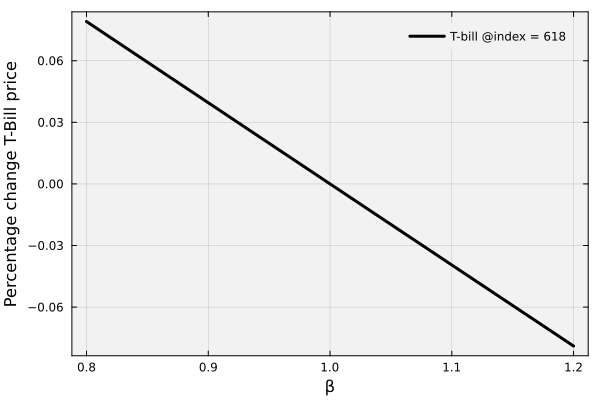

In [18]:
let
    q = plot(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
    plot(q, theorem_1_simulation_array[:,1], theorem_1_simulation_array[:,2], lw=3, c=:black, xlabel="β", 
            ylabel="Percentage change T-Bill price", label="T-bill @index = $(random_bill_index)")
end

### Discussion: Is the price-versus-investment-rate slope negative?
If price is inversely related to the quoted investment rate, then the slope of price versus $y_I$ should be negative. Let's compute that slope from the simulation array and store it in `slope`.

> __Idea:__ Use the [@assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) to test if the slope is negative: if $\text{slope}>0$, i.e., `Theorem 1` is not supported, this test will throw an [AssertionError](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError), otherwise the `Theorem 1` is supported by simulation

What do we see?

In [19]:
slope = (theorem_1_simulation_array[end,4] - theorem_1_simulation_array[1,4])/(theorem_1_simulation_array[end,3] - theorem_1_simulation_array[1,3]);
@assert (slope < 0.0)  # Verify Theorem 1: negative slope confirms inverse price-yield relationship

___

## Summary

This example priced zero-coupon Treasury bills from their purchase-date outflow and single face-value payment at maturity, then examined how the quoted investment rate affects price.

> __Key Takeaways:__
>
> * __A T-bill has one terminal cash inflow:__ With no coupon payments, valuation reduces to discounting the face value from maturity to the purchase date.
> * __The pricing convention must be stated explicitly:__ A generic equivalent-yield calculation and the Treasury auction quotation formula can produce different values unless their day-count and rate conventions are reconciled.
> * __Price and yield move inversely:__ Holding face value and maturity fixed, a larger quoted investment rate implies a lower purchase price; the perturbation experiment confirms the negative slope.

Treasury-bill valuation is mechanically simple, but accurate reconstruction of an auction price still depends on using the correct dates and quotation convention.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___